# Домашнее задание к семинарам 08-09 (HW08-09)
Тема: PyTorch 101 b основы оптимизации обучения.
Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).
Часть S09: learning rate диагностика, Adam vs SGD+momentum, weight decay.

HW08-09 выполняется в личном репозитории студента (на основе шаблона курса) в папке `homeworks/HW08-09/`.

## 1. Цель

Закрепить:

- базовые сущности PyTorch: `Tensor`, `Dataset/DataLoader`, `nn.Module`, loss, optimizer, цикл обучения;
- корректный режим обучения/валидации: `model.train()` / `model.eval()` и `torch.no_grad()`;
- практическое управление переобучением: **Dropout**, **BatchNorm**, **EarlyStopping**;
- базовые рычаги обучения: learning rate (плохой/хороший), сравнение Adam и SGD+momentum, использование weight decay;
- аккуратное оформление результатов: один ноутбук, короткий отчёт, артефакты эксперимента.

## 2. Задание

### 2.1. Структура для HW08-09 (обязательно)

1. В корне репозитория должна быть папка `homeworks/` (создать, если её ещё нет).
2. Внутри `homeworks/` создать папку `HW08-09/`.
3. В папке `homeworks/HW08-09/` создать:

- основной ноутбук: `HW08-09.ipynb`
- отчёт: `report.md`
- папку для артефактов: `artifacts/`
  - рекомендуется внутри `artifacts/` завести подпапку `figures/` для графиков


### 2.2. Учебные датасеты (выбрать один из трёх)

Выберите **один** датасет из списка (все доступны через `torchvision`):

- Вариант A: `KMNIST` (рекомендуется по умолчанию)
- Вариант B: `EMNIST(split="balanced")`
- Вариант C: `CIFAR10` (MLP будет работать хуже – это нормально; важны сравнения и выводы)

Требования к данным:

- используйте стандартный train/test из torchvision;
- сделайте **валидацию**: отделите `val` от `train` (например, 80/20), разбиение должно быть воспроизводимым (фиксированный seed);
- путь к данным в ноутбуке – стандартный (через torchvision), без абсолютных путей к домашним каталогам.

# Выбранный датасэт: Вариант B

### 2.3. Содержание ноутбука `HW08-09.ipynb` (обязательно)

В ноутбуке `homeworks/HW08-09/HW08-09.ipynb` реализуйте и покажите следующие блоки.

#### 2.3.1. Импорты, seed и устройство

1) Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).  
2) Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).  
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
import csv
import json
import copy

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


#### 2.3.2. Данные и DataLoader

1) Загрузить выбранный датасет через `torchvision.datasets.*`.  
2) Определить `transform` (минимум `ToTensor()`, нормализация – по желанию).  
3) Сделать разбиение `train/val` из train-части с фиксированным seed.  
4) Создать `DataLoader` для train/val/test.  
5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

# Воспроизводимое разбиение train/val (seed зафиксирован явно)
VAL_SPLIT_SEED = SEED

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

g = torch.Generator()
g.manual_seed(VAL_SPLIT_SEED)

train, val = torch.utils.data.random_split(
    train_full, [train_size, val_size], generator=g
)

print(f"Seed разбиения: {VAL_SPLIT_SEED}")
print(f"Размер train : {len(train)}")
print(f"Размер val   : {len(val)}")

BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val,   batch_size=BATCH_SIZE)
test_loader  = torch.utils.data.DataLoader(test,  batch_size=BATCH_SIZE)

Seed разбиения: 42
Размер train : 90240
Размер val   : 22560


In [3]:
num_classes = len(train_full.classes)
print(f"Количество классов: {num_classes}")

Количество классов: 47


Shape изображений (batch, channels, height, width): torch.Size([64, 1, 28, 28])
Shape меток (batch,): torch.Size([64])
Min value в батче: -1.0000
Max value в батче: 1.0000
Mean value в батче: -0.6162
Уникальные метки в батче: [ 0  2  3  4  7  8  9 10 11 12 13 14 17 18 19 23 24 28 29 30 31 32 33 34
 35 36 38 39 40 41 42 43 44 46]


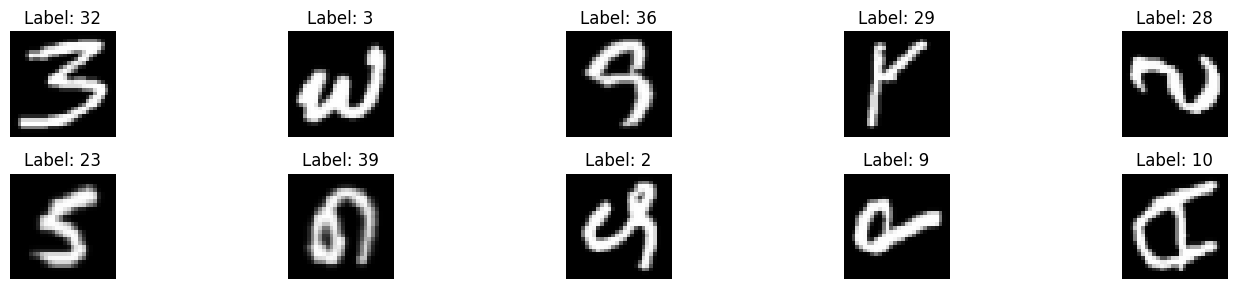

In [4]:
# Получаем один батч из train_loader
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

print(f"Shape изображений (batch, channels, height, width): {images.shape}")
print(f"Shape меток (batch,): {labels.shape}")
print(f"Min value в батче: {images.min().item():.4f}")
print(f"Max value в батче: {images.max().item():.4f}")
print(f"Mean value в батче: {images.mean().item():.4f}")

unique_labels = torch.unique(labels)
print(f"Уникальные метки в батче: {unique_labels.cpu().numpy()}")

plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = images[i].cpu().squeeze().numpy()
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

#### 2.3.3. Модель MLP и цикл обучения

1) Реализовать MLP как `nn.Module` (Flatten, Linear, …, logits).  
2) Выбрать:
    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  

3) Реализовать функции (или эквивалент):

    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  

4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.


In [5]:
# MLP реализован как полноценный nn.Module
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 784,
        hidden1: int = 256,
        hidden2: int = 128,
        num_classes: int = 47,
        use_batchnorm: bool = False,
        dropout_p: float = 0.0,
    ):
        super().__init__()
        self.use_batchnorm = use_batchnorm
        self.dropout_p = dropout_p

        layers = [nn.Flatten()]

        # Первый скрытый слой
        layers.append(nn.Linear(input_dim, hidden1))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))
        layers.append(nn.ReLU())
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))

        # Второй скрытый слой
        layers.append(nn.Linear(hidden1, hidden2))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))
        layers.append(nn.ReLU())
        if dropout_p > 0:
            layers.append(nn.Dropout(dropout_p))

        # Выходной слой
        layers.append(nn.Linear(hidden2, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def summary_str(self) -> str:
        """Краткое текстовое описание архитектуры для runs.csv."""
        bn  = "-BN" if self.use_batchnorm else ""
        dr  = f"-Drop({self.dropout_p})" if self.dropout_p > 0 else ""
        return (
            f"Flatten-Linear(784,256){bn}-ReLU{dr}"
            f"-Linear(256,128){bn}-ReLU{dr}"
            f"-Linear(128,{num_classes})"
        )


# Проверка: быстрый прогон одного батча
_test_model = MLP(use_batchnorm=True, dropout_p=0.3, num_classes=num_classes).to(device)
_x = torch.randn(4, 1, 28, 28).to(device)
print("Forward pass shape:", _test_model(_x).shape)  # должно быть [4, 47]
del _test_model, _x

Forward pass shape: torch.Size([4, 47])


In [6]:
# Функции обучения и оценки
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        preds    = out.argmax(dim=1)
        correct  += (preds == y).sum().item()
        total    += y.size(0)
        total_loss += loss.item() * x.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            preds   = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            total_loss += loss.item() * x.size(0)
    return total_loss / total, correct / total

## 3. Эксперименты

В домашней работе есть две части: (A) регуляризация (S08) и (B) оптимизация (S09).
Все результаты прогонов фиксируются в `artifacts/runs.csv` (см. раздел 4).

### 3.1. Часть A (S08): регуляризация и переобучение (обязательно)

Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.

- **E1 (base)**: MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
- **E2 (Dropout)**: как E1, но добавить Dropout (например, p=0.2-0.5).
- **E3 (BatchNorm)**: как E1, но добавить BatchNorm (между Linear и активацией).
- **E4 (EarlyStopping)**: выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
  - именно E4 считается "лучшей моделью домашки" и из него сохраняется `best_model.pt`.

Важно:

- сравнение должно быть корректным: одинаковые split/train settings (где уместно), одинаковое число эпох (кроме early stopping);
- test-часть используйте **один раз**: только для финальной оценки лучшей модели после выбора по val.

### Инициализация runs.csv и вспомогательная функция записи

In [7]:
os.makedirs('artifacts/figures', exist_ok=True)

# Инициализируем CSV с полным набором обязательных колонок
with open('artifacts/runs.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([
        'experiment_id',
        'dataset',
        'seed',
        'model_summary',
        'optimizer',
        'lr',
        'momentum',
        'weight_decay',
        'epochs_trained',
        'best_val_accuracy',
        'best_val_loss',
    ])


def save_result(
    experiment_id: str,
    model_summary: str,
    optimizer_name: str,
    lr: float,
    momentum: float,
    weight_decay: float,
    epochs_trained: int,
    best_val_accuracy: float,
    best_val_loss: float,
):
    with open('artifacts/runs.csv', 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            experiment_id,
            'EMNIST_balanced',
            SEED,
            model_summary,
            optimizer_name,
            lr,
            momentum,
            weight_decay,
            epochs_trained,
            round(best_val_accuracy, 4),
            round(best_val_loss, 4),
        ])

## Эксперимент E1 (base)

In [8]:
torch.manual_seed(SEED)
model_e1 = MLP(use_batchnorm=False, dropout_p=0.0, num_classes=num_classes).to(device)

criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model_e1.parameters(), lr=0.001)

best_val_acc  = 0.0
best_val_loss = float('inf')
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_e1, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_e1, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_val_loss = v_loss
    print(f"Epoch {epoch+1:2d}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result(
    experiment_id='E1_Base',
    model_summary=model_e1.summary_str(),
    optimizer_name='Adam',
    lr=0.001,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc,
    best_val_loss=best_val_loss,
)
acc_e1 = best_val_acc
print(f"E1 Итог: Best Val Acc = {best_val_acc:.4f}")

Epoch  1: Train Acc=0.6530 | Val Acc=0.7426
Epoch  2: Train Acc=0.7816 | Val Acc=0.7955
Epoch  3: Train Acc=0.8098 | Val Acc=0.7996
Epoch  4: Train Acc=0.8248 | Val Acc=0.8223
Epoch  5: Train Acc=0.8347 | Val Acc=0.8270
Epoch  6: Train Acc=0.8426 | Val Acc=0.8283
Epoch  7: Train Acc=0.8484 | Val Acc=0.8278
Epoch  8: Train Acc=0.8543 | Val Acc=0.8316
Epoch  9: Train Acc=0.8579 | Val Acc=0.8305
Epoch 10: Train Acc=0.8612 | Val Acc=0.8250
Epoch 11: Train Acc=0.8641 | Val Acc=0.8360
Epoch 12: Train Acc=0.8688 | Val Acc=0.8263
Epoch 13: Train Acc=0.8725 | Val Acc=0.8326
Epoch 14: Train Acc=0.8749 | Val Acc=0.8276
Epoch 15: Train Acc=0.8759 | Val Acc=0.8253
E1 Итог: Best Val Acc = 0.8360


## Эксперимент E2 (Dropout)
Добавляем `Dropout(0.3)`. Это должно уменьшить переобучение.

In [9]:
torch.manual_seed(SEED)
model_e2 = MLP(use_batchnorm=False, dropout_p=0.3, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_e2.parameters(), lr=0.001)

best_val_acc  = 0.0
best_val_loss = float('inf')
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_e2, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_e2, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_val_loss = v_loss
    print(f"Epoch {epoch+1:2d}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result(
    experiment_id='E2_Dropout',
    model_summary=model_e2.summary_str(),
    optimizer_name='Adam',
    lr=0.001,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc,
    best_val_loss=best_val_loss,
)
acc_e2 = best_val_acc
print(f"E2 Итог: Best Val Acc = {best_val_acc:.4f}")

Epoch  1: Train Acc=0.5447 | Val Acc=0.7287
Epoch  2: Train Acc=0.6749 | Val Acc=0.7663
Epoch  3: Train Acc=0.7017 | Val Acc=0.7793
Epoch  4: Train Acc=0.7166 | Val Acc=0.7939
Epoch  5: Train Acc=0.7280 | Val Acc=0.7955
Epoch  6: Train Acc=0.7331 | Val Acc=0.8012
Epoch  7: Train Acc=0.7361 | Val Acc=0.7996
Epoch  8: Train Acc=0.7401 | Val Acc=0.8060
Epoch  9: Train Acc=0.7442 | Val Acc=0.8129
Epoch 10: Train Acc=0.7453 | Val Acc=0.8105
Epoch 11: Train Acc=0.7482 | Val Acc=0.8160
Epoch 12: Train Acc=0.7505 | Val Acc=0.8133
Epoch 13: Train Acc=0.7539 | Val Acc=0.8180
Epoch 14: Train Acc=0.7558 | Val Acc=0.8112
Epoch 15: Train Acc=0.7552 | Val Acc=0.8156
E2 Итог: Best Val Acc = 0.8180


## Эксперимент E3 (BatchNorm)
Добавляем `BatchNorm1d`. Это должно ускорить обучение и улучшить стабильность.

In [10]:
torch.manual_seed(SEED)
model_e3 = MLP(use_batchnorm=True, dropout_p=0.0, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_e3.parameters(), lr=0.001)

best_val_acc  = 0.0
best_val_loss = float('inf')
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_e3, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_e3, val_loader, criterion)
    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_val_loss = v_loss
    print(f"Epoch {epoch+1:2d}: Train Acc={t_acc:.4f} | Val Acc={v_acc:.4f}")

save_result(
    experiment_id='E3_BatchNorm',
    model_summary=model_e3.summary_str(),
    optimizer_name='Adam',
    lr=0.001,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc,
    best_val_loss=best_val_loss,
)
acc_e3 = best_val_acc
print(f"E3 Итог: Best Val Acc = {best_val_acc:.4f}")

Epoch  1: Train Acc=0.7337 | Val Acc=0.8090
Epoch  2: Train Acc=0.8204 | Val Acc=0.8313
Epoch  3: Train Acc=0.8389 | Val Acc=0.8346
Epoch  4: Train Acc=0.8512 | Val Acc=0.8452
Epoch  5: Train Acc=0.8613 | Val Acc=0.8462
Epoch  6: Train Acc=0.8676 | Val Acc=0.8480
Epoch  7: Train Acc=0.8734 | Val Acc=0.8472
Epoch  8: Train Acc=0.8790 | Val Acc=0.8519
Epoch  9: Train Acc=0.8829 | Val Acc=0.8502
Epoch 10: Train Acc=0.8867 | Val Acc=0.8500
Epoch 11: Train Acc=0.8909 | Val Acc=0.8533
Epoch 12: Train Acc=0.8940 | Val Acc=0.8500
Epoch 13: Train Acc=0.8960 | Val Acc=0.8510
Epoch 14: Train Acc=0.9000 | Val Acc=0.8485
Epoch 15: Train Acc=0.9022 | Val Acc=0.8479
E3 Итог: Best Val Acc = 0.8533


## Эксперимент E4 (EarlyStopping)
Выбираем лучшую модель из E2 или E3 и обучаем с ранней остановкой.
Как мы видим, E3 лучше, чем E2, поэтому используем её.

In [11]:
torch.manual_seed(SEED)
model_e4 = MLP(use_batchnorm=True, dropout_p=0.0, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_e4.parameters(), lr=0.001)

best_val_acc      = 0.0
best_val_loss     = float('inf')
best_model_state  = None
patience          = 5
patience_counter  = 0
epochs_max        = 30
final_epoch       = 0

# История E4 для графиков
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs_max):
    t_loss, t_acc = train_one_epoch(model_e4, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_e4, val_loader, criterion)
    final_epoch = epoch + 1

    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc     = v_acc
        best_val_loss    = v_loss
        best_model_state = copy.deepcopy(model_e4.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch+1:2d}: Train Acc={t_acc:.4f} | "
        f"Val Acc={v_acc:.4f} | Patience {patience_counter}/{patience}"
    )

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# Восстанавливаем лучшие веса
if best_model_state:
    model_e4.load_state_dict(best_model_state)

save_result(
    experiment_id='E4_EarlyStop',
    model_summary=model_e4.summary_str(),
    optimizer_name='Adam',
    lr=0.001,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=final_epoch,
    best_val_accuracy=best_val_acc,
    best_val_loss=best_val_loss,
)

# Сохраняем лучшую модель
torch.save(model_e4.state_dict(), 'artifacts/best_model.pt')
print(f"E4 Итог: Best Val Acc = {best_val_acc:.4f}, Epochs trained = {final_epoch}")

Epoch  1: Train Acc=0.7337 | Val Acc=0.8090 | Patience 0/5
Epoch  2: Train Acc=0.8204 | Val Acc=0.8313 | Patience 0/5
Epoch  3: Train Acc=0.8389 | Val Acc=0.8346 | Patience 0/5
Epoch  4: Train Acc=0.8512 | Val Acc=0.8452 | Patience 0/5
Epoch  5: Train Acc=0.8613 | Val Acc=0.8462 | Patience 0/5
Epoch  6: Train Acc=0.8676 | Val Acc=0.8480 | Patience 0/5
Epoch  7: Train Acc=0.8734 | Val Acc=0.8472 | Patience 1/5
Epoch  8: Train Acc=0.8790 | Val Acc=0.8519 | Patience 0/5
Epoch  9: Train Acc=0.8829 | Val Acc=0.8502 | Patience 1/5
Epoch 10: Train Acc=0.8867 | Val Acc=0.8500 | Patience 2/5
Epoch 11: Train Acc=0.8909 | Val Acc=0.8533 | Patience 0/5
Epoch 12: Train Acc=0.8940 | Val Acc=0.8500 | Patience 1/5
Epoch 13: Train Acc=0.8960 | Val Acc=0.8510 | Patience 2/5
Epoch 14: Train Acc=0.9000 | Val Acc=0.8485 | Patience 3/5
Epoch 15: Train Acc=0.9022 | Val Acc=0.8479 | Patience 4/5
Epoch 16: Train Acc=0.9053 | Val Acc=0.8509 | Patience 5/5
Early stopping triggered.
E4 Итог: Best Val Acc = 0.8533

## Графики лучшей модели (E4)

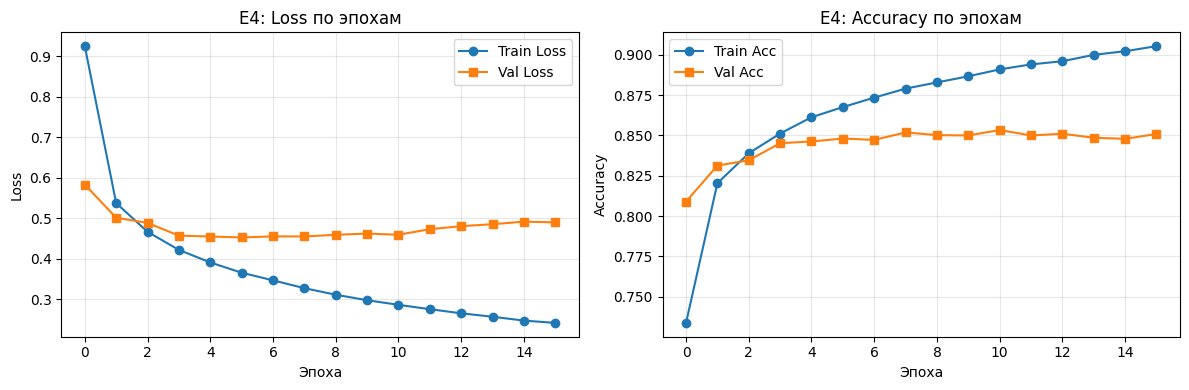

Графики сохранены в artifacts/figures/curves_best.png


In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'],   label='Val Loss',   marker='s')
plt.title('E4: Loss по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'],   label='Val Acc',   marker='s')
plt.title('E4: Accuracy по эпохам')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
plt.show()
print("Графики сохранены в artifacts/figures/curves_best.png")

## Финальный тест на test set

In [13]:
model_e4.load_state_dict(torch.load('artifacts/best_model.pt'))
test_loss, test_acc = evaluate(model_e4, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.4f}")

# Записываем тестовый результат в CSV
save_result(
    experiment_id='E4_Best_TEST',
    model_summary=model_e4.summary_str(),
    optimizer_name='Adam',
    lr=0.001,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=final_epoch,
    best_val_accuracy=best_val_acc,
    best_val_loss=best_val_loss,
)

Test Accuracy: 0.8513


### 3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на **фиксированной архитектуре** (той же, что в E4 по слоям/нейронам/Dropout/BN).

- **O1 (LR слишком большой)**: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
- **O2 (LR слишком маленький)**: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
- **O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4).
  - lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
  - обучить 10-15 эпох (или меньше, если на CPU долго).

Важно:

- O1 и O2 нужны **только для диагностики**, их модели не сохраняются как best.
- "Лучшая модель домашки" выбирается в части A (E4) по `val_accuracy` и затем проверяется на test.

## Эксперимент O1: LR слишком большой

In [14]:
o1_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

torch.manual_seed(SEED)
model_o1 = MLP(use_batchnorm=True, dropout_p=0.0, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_o1.parameters(), lr=0.1)

best_val_acc_o1  = 0.0
best_val_loss_o1 = float('inf')
epochs = 6

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_o1, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_o1, val_loader, criterion)
    o1_history['train_loss'].append(t_loss)
    o1_history['train_acc'].append(t_acc)
    o1_history['val_loss'].append(v_loss)
    o1_history['val_acc'].append(v_acc)
    if v_acc > best_val_acc_o1:
        best_val_acc_o1  = v_acc
        best_val_loss_o1 = v_loss
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result(
    experiment_id='O1_LR_TooBig',
    model_summary=model_o1.summary_str(),
    optimizer_name='Adam',
    lr=0.1,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc_o1,
    best_val_loss=best_val_loss_o1,
)
print(f"O1 Итог: Best Val Acc = {best_val_acc_o1:.4f}")

Epoch 1: Train Loss=1.2095 Acc=0.6376 | Val Loss=0.9342 Acc=0.7136
Epoch 2: Train Loss=0.8976 Acc=0.7188 | Val Loss=0.7666 Acc=0.7541
Epoch 3: Train Loss=0.8109 Acc=0.7449 | Val Loss=0.7087 Acc=0.7683
Epoch 4: Train Loss=0.7608 Acc=0.7571 | Val Loss=0.7068 Acc=0.7771
Epoch 5: Train Loss=0.7384 Acc=0.7632 | Val Loss=0.7032 Acc=0.7738
Epoch 6: Train Loss=0.6975 Acc=0.7743 | Val Loss=0.6986 Acc=0.7837
O1 Итог: Best Val Acc = 0.7837


## Эксперимент O2: LR слишком маленький

In [15]:
o2_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

torch.manual_seed(SEED)
model_o2 = MLP(use_batchnorm=True, dropout_p=0.0, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_o2.parameters(), lr=1e-5)

best_val_acc_o2  = 0.0
best_val_loss_o2 = float('inf')
epochs = 6

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_o2, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_o2, val_loader, criterion)
    o2_history['train_loss'].append(t_loss)
    o2_history['train_acc'].append(t_acc)
    o2_history['val_loss'].append(v_loss)
    o2_history['val_acc'].append(v_acc)
    if v_acc > best_val_acc_o2:
        best_val_acc_o2  = v_acc
        best_val_loss_o2 = v_loss
    print(f"Epoch {epoch+1}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result(
    experiment_id='O2_LR_TooSmall',
    model_summary=model_o2.summary_str(),
    optimizer_name='Adam',
    lr=1e-5,
    momentum=0.0,
    weight_decay=0.0,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc_o2,
    best_val_loss=best_val_loss_o2,
)
print(f"O2 Итог: Best Val Acc = {best_val_acc_o2:.4f}")

Epoch 1: Train Loss=3.3299 Acc=0.2295 | Val Loss=2.9065 Acc=0.4069
Epoch 2: Train Loss=2.6808 Acc=0.4767 | Val Loss=2.4435 Acc=0.5385
Epoch 3: Train Loss=2.3077 Acc=0.5654 | Val Loss=2.1275 Acc=0.6030
Epoch 4: Train Loss=2.0225 Acc=0.6129 | Val Loss=1.8675 Acc=0.6388
Epoch 5: Train Loss=1.7942 Acc=0.6444 | Val Loss=1.6687 Acc=0.6629
Epoch 6: Train Loss=1.6089 Acc=0.6680 | Val Loss=1.5033 Acc=0.6855
O2 Итог: Best Val Acc = 0.6855


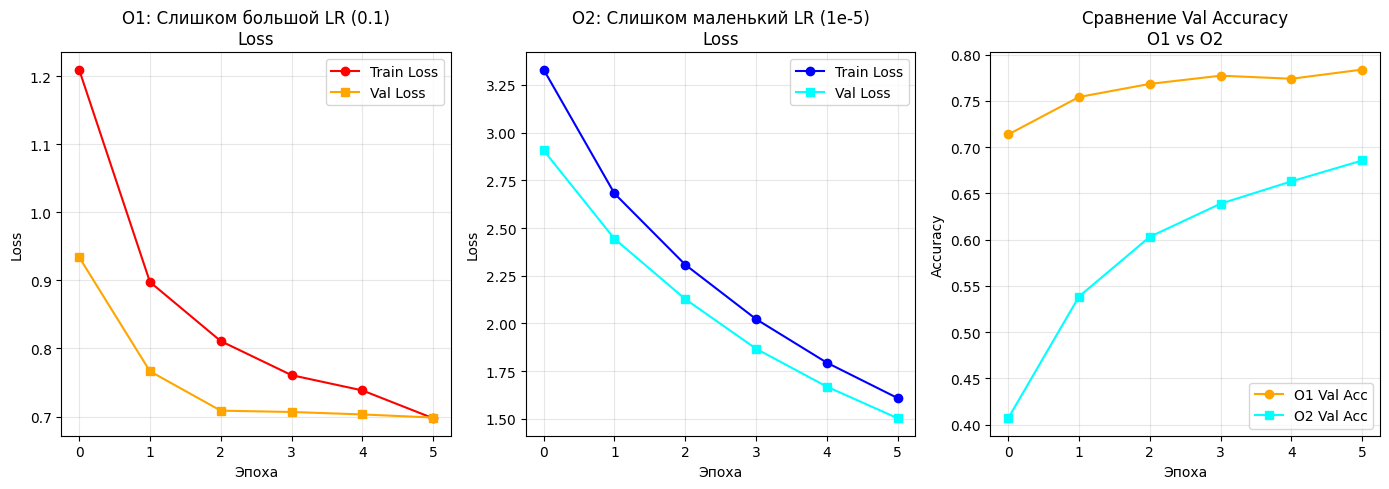

Графики LR диагностики сохранены в artifacts/figures/curves_lr_extremes.png


In [16]:
# Графики для диагностики LR
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(o1_history['train_loss'], label='Train Loss', marker='o', color='red')
plt.plot(o1_history['val_loss'],   label='Val Loss',   marker='s', color='orange')
plt.title('O1: Слишком большой LR (0.1)\nLoss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(o2_history['train_loss'], label='Train Loss', marker='o', color='blue')
plt.plot(o2_history['val_loss'],   label='Val Loss',   marker='s', color='cyan')
plt.title('O2: Слишком маленький LR (1e-5)\nLoss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(o1_history['val_acc'], label='O1 Val Acc', marker='o', color='orange')
plt.plot(o2_history['val_acc'], label='O2 Val Acc', marker='s', color='cyan')
plt.title('Сравнение Val Accuracy\nO1 vs O2')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Графики LR диагностики сохранены в artifacts/figures/curves_lr_extremes.png")

## Эксперимент O3: SGD + Momentum + Weight Decay

In [17]:
o3_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

O3_LR           = 0.01
O3_MOMENTUM     = 0.9
O3_WEIGHT_DECAY = 1e-4

torch.manual_seed(SEED)
model_o3 = MLP(use_batchnorm=True, dropout_p=0.0, num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model_o3.parameters(),
    lr=O3_LR,
    momentum=O3_MOMENTUM,
    weight_decay=O3_WEIGHT_DECAY,
)

best_val_acc_o3  = 0.0
best_val_loss_o3 = float('inf')
epochs = 15

for epoch in range(epochs):
    t_loss, t_acc = train_one_epoch(model_o3, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model_o3, val_loader, criterion)
    o3_history['train_loss'].append(t_loss)
    o3_history['train_acc'].append(t_acc)
    o3_history['val_loss'].append(v_loss)
    o3_history['val_acc'].append(v_acc)
    if v_acc > best_val_acc_o3:
        best_val_acc_o3  = v_acc
        best_val_loss_o3 = v_loss
    print(f"Epoch {epoch+1:2d}: Train Loss={t_loss:.4f} Acc={t_acc:.4f} | Val Loss={v_loss:.4f} Acc={v_acc:.4f}")

save_result(
    experiment_id='O3_SGD_Momentum_WD',
    model_summary=model_o3.summary_str(),
    optimizer_name='SGD',
    lr=O3_LR,
    momentum=O3_MOMENTUM,
    weight_decay=O3_WEIGHT_DECAY,
    epochs_trained=epochs,
    best_val_accuracy=best_val_acc_o3,
    best_val_loss=best_val_loss_o3,
)
print(f"O3 Итог: Best Val Acc = {best_val_acc_o3:.4f}")

Epoch  1: Train Loss=0.9630 Acc=0.7210 | Val Loss=0.6021 Acc=0.8028
Epoch  2: Train Loss=0.5630 Acc=0.8139 | Val Loss=0.5161 Acc=0.8313
Epoch  3: Train Loss=0.4870 Acc=0.8347 | Val Loss=0.4929 Acc=0.8320
Epoch  4: Train Loss=0.4407 Acc=0.8478 | Val Loss=0.4740 Acc=0.8400
Epoch  5: Train Loss=0.4125 Acc=0.8550 | Val Loss=0.4626 Acc=0.8437
Epoch  6: Train Loss=0.3865 Acc=0.8632 | Val Loss=0.4638 Acc=0.8455
Epoch  7: Train Loss=0.3685 Acc=0.8678 | Val Loss=0.4537 Acc=0.8473
Epoch  8: Train Loss=0.3494 Acc=0.8729 | Val Loss=0.4568 Acc=0.8517
Epoch  9: Train Loss=0.3359 Acc=0.8768 | Val Loss=0.4475 Acc=0.8515
Epoch 10: Train Loss=0.3220 Acc=0.8806 | Val Loss=0.4488 Acc=0.8489
Epoch 11: Train Loss=0.3136 Acc=0.8833 | Val Loss=0.4550 Acc=0.8512
Epoch 12: Train Loss=0.3035 Acc=0.8861 | Val Loss=0.4581 Acc=0.8489
Epoch 13: Train Loss=0.2949 Acc=0.8896 | Val Loss=0.4606 Acc=0.8523
Epoch 14: Train Loss=0.2883 Acc=0.8919 | Val Loss=0.4528 Acc=0.8502
Epoch 15: Train Loss=0.2787 Acc=0.8940 | Val Los

In [18]:
# Сохраняем полную конфигурацию лучшей модели (E4) со всеми гиперпараметрами
best_config = {
    "experiment": "E4_Best",
    "seed": SEED,
    "val_split_seed": VAL_SPLIT_SEED,
    "architecture": {
        "type": "MLP",
        "input_dim": 784,
        "hidden1": 256,
        "hidden2": 128,
        "num_classes": num_classes,
        "use_batchnorm": True,
        "dropout_p": 0.0,
        "layers": [
            {"type": "Flatten"},
            {"type": "Linear",      "in": 784, "out": 256},
            {"type": "BatchNorm1d", "num_features": 256},
            {"type": "ReLU"},
            {"type": "Linear",      "in": 256, "out": 128},
            {"type": "BatchNorm1d", "num_features": 128},
            {"type": "ReLU"},
            {"type": "Linear",      "in": 128, "out": num_classes},
        ],
    },
    "training": {
        "seed": SEED,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "dropout_p": 0.0,
        "use_batchnorm": True,
        "batch_size": BATCH_SIZE,
        "epochs_max": 30,
        "epochs_actual": final_epoch,
        "early_stopping": {
            "patience": 5,
            "metric": "val_accuracy",
        },
    },
    "dataset": {
        "name": "EMNIST_balanced",
        "train_samples": len(train),
        "val_samples": len(val),
        "test_samples": len(test),
        "num_classes": num_classes,
    },
    "results": {
        "best_val_accuracy": round(best_val_acc, 4),
        "best_val_loss": round(best_val_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "test_loss": round(test_loss, 4),
    },
}

with open('artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

print("Конфигурация сохранена в artifacts/best_config.json")
print(f"Best Val Accuracy : {best_config['results']['best_val_accuracy']}")
print(f"Test Accuracy     : {best_config['results']['test_accuracy']}")
print(f"Epochs trained    : {final_epoch}")

Конфигурация сохранена в artifacts/best_config.json
Best Val Accuracy : 0.8533
Test Accuracy     : 0.8513
Epochs trained    : 16
